In [ ]:
# ============================================================
# Step 1 – Check uploaded final-corpus PDF files
# ============================================================

import os

UPLOAD_FOLDER = "/content"

pdf_files = [
    file for file in os.listdir(UPLOAD_FOLDER)
    if file.lower().endswith(".pdf")
]

print("Number of PDF files found:", len(pdf_files))
print("\nPDF files:")

for file in sorted(pdf_files):
    print(file)

Number of PDF files found: 24

PDF files:
eu_2018_ai_for_europe.pdf
eu_2018_coordinated_plan_ai.pdf
eu_2019_ethics_guidelines_trustworthy_ai.pdf
eu_2020_white_paper_ai.pdf
eu_2021_coordinated_plan_ai_review.pdf
eu_2021_fostering_european_approach_ai_communication.pdf
eu_2024_ai_act.pdf
eu_2024_ai_pact.pdf
eu_2025_ai_continent_action_plan.pdf
eu_2025_apply_ai_strategy.pdf
eu_2025_digital_omnibus_ai.pdf
eu_2025_guidelines_prohibited_ai_practices.pdf
us_2020_naiia.pdf
us_2022_ai_bill_of_rights.pdf
us_2023_eo_14110.pdf
us_2023_nist_ai_rmf.pdf
us_2025_america_ai_action_plan.pdf
us_2025_california_sb_420.pdf
us_2025_eo_14141_ai_infrastructure.pdf
us_2025_eo_14179_removing_barriers_ai.pdf
us_2025_eo_14318_data_center_infrastructure.pdf
us_2025_eo_14320_ai_technology_stack_exports.pdf
us_2025_eo_14365_national_policy_framework_ai.pdf
us_2026_national_policy_framework_ai_legislative_recommendations.pdf


In [ ]:
# ============================================================
# Step 2A – Install required packages
# ============================================================

!pip install pymupdf spacy plotly wordcloud openpyxl
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 55.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 81.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ============================================================
# Step 2B – Import libraries
# ============================================================

import fitz
import re
import os
import pandas as pd
import spacy
import plotly.express as px
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

nlp = spacy.load("en_core_web_sm")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ============================================================
# Step 3 – Define metadata for the 24-document research corpus
# ============================================================

documents = [
    # ----------------------------
    # EU documents
    # ----------------------------
    {
        "document_id": "EU_01",
        "document": "Communication: Artificial Intelligence for Europe",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Policy communication / strategy",
        "file_name": "eu_2018_ai_for_europe.pdf",
        "path": "/content/eu_2018_ai_for_europe.pdf",
        "year": 2018,
        "institution": "European Commission",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Published policy document",
        "notes": "Early EU AI strategy."
    },
    {
        "document_id": "EU_02",
        "document": "Coordinated Plan on Artificial Intelligence",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Policy strategy / coordinated plan",
        "file_name": "eu_2018_coordinated_plan_ai.pdf",
        "path": "/content/eu_2018_coordinated_plan_ai.pdf",
        "year": 2018,
        "institution": "European Commission / Member States",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Published policy coordination document",
        "notes": "Formal policy coordination instrument; non-binding."
    },
    {
        "document_id": "EU_03",
        "document": "Ethics Guidelines for Trustworthy AI",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Expert group guidelines / soft law",
        "file_name": "eu_2019_ethics_guidelines_trustworthy_ai.pdf",
        "path": "/content/eu_2019_ethics_guidelines_trustworthy_ai.pdf",
        "year": 2019,
        "institution": "High-Level Expert Group on AI / European Commission",
        "legal_force_multiplier": 0.70,
        "status_assumption": "Non-binding expert guidelines",
        "notes": "Trustworthy AI and human-centric safeguards."
    },
    {
        "document_id": "EU_04",
        "document": "White Paper on Artificial Intelligence: A European approach to excellence and trust",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Policy communication / White Paper",
        "file_name": "eu_2020_white_paper_ai.pdf",
        "path": "/content/eu_2020_white_paper_ai.pdf",
        "year": 2020,
        "institution": "European Commission",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Published policy document",
        "notes": "Excellence and trust framing."
    },
    {
        "document_id": "EU_05",
        "document": "Communication: Fostering a European approach to Artificial Intelligence",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Policy communication / strategy",
        "file_name": "eu_2021_fostering_european_approach_ai_communication.pdf",
        "path": "/content/eu_2021_fostering_european_approach_ai_communication.pdf",
        "year": 2021,
        "institution": "European Commission",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Published policy communication",
        "notes": "Strategic policy document."
    },
    {
        "document_id": "EU_06",
        "document": "Coordinated Plan on Artificial Intelligence 2021 Review",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Policy strategy / coordinated plan",
        "file_name": "eu_2021_coordinated_plan_ai_review.pdf",
        "path": "/content/eu_2021_coordinated_plan_ai_review.pdf",
        "year": 2021,
        "institution": "European Commission / Member States",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Published policy coordination document",
        "notes": "Formal policy coordination instrument; non-binding."
    },
    {
        "document_id": "EU_07",
        "document": "Regulation (EU) 2024/1689: Artificial Intelligence Act",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Binding regulation",
        "file_name": "eu_2024_ai_act.pdf",
        "path": "/content/eu_2024_ai_act.pdf",
        "year": 2024,
        "institution": "European Union",
        "legal_force_multiplier": 1.50,
        "status_assumption": "Adopted binding legislation",
        "notes": "Core EU AI regulatory instrument."
    },
    {
        "document_id": "EU_08",
        "document": "AI Pact",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Voluntary commitment / implementation initiative",
        "file_name": "eu_2024_ai_pact.pdf",
        "path": "/content/eu_2024_ai_pact.pdf",
        "year": 2024,
        "institution": "European Commission / AI Office",
        "legal_force_multiplier": 0.60,
        "status_assumption": "Voluntary initiative",
        "notes": "Voluntary early implementation initiative."
    },
    {
        "document_id": "EU_09",
        "document": "Apply AI Strategy",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Policy strategy / adoption strategy",
        "file_name": "eu_2025_apply_ai_strategy.pdf",
        "path": "/content/eu_2025_apply_ai_strategy.pdf",
        "year": 2025,
        "institution": "European Commission",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Published policy strategy",
        "notes": "AI adoption and deployment strategy."
    },
    {
        "document_id": "EU_10",
        "document": "Communication from the Commission (2025) AI Continent Action Plan",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Policy communication / strategy",
        "file_name": "eu_2025_ai_continent_action_plan.pdf",
        "path": "/content/eu_2025_ai_continent_action_plan.pdf",
        "year": 2025,
        "institution": "European Commission",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Published policy communication",
        "notes": "AI factories, gigafactories and AI continent framing."
    },
    {
        "document_id": "EU_11",
        "document": "Guidelines on prohibited artificial intelligence practices established by Regulation (EU) 2024/1689",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Commission guidelines / AI Act implementation guidance",
        "file_name": "eu_2025_guidelines_prohibited_ai_practices.pdf",
        "path": "/content/eu_2025_guidelines_prohibited_ai_practices.pdf",
        "year": 2025,
        "institution": "European Commission",
        "legal_force_multiplier": 0.70,
        "status_assumption": "Guidance document under the AI Act",
        "notes": "Interpretative guidance; not legislation."
    },
    {
        "document_id": "EU_12",
        "document": "Digital Omnibus simplification proposal",
        "jurisdiction": "EU",
        "plot_group": "EU",
        "document_type": "Assumed adopted binding legislation",
        "file_name": "eu_2025_digital_omnibus_ai.pdf",
        "path": "/content/eu_2025_digital_omnibus_ai.pdf",
        "year": 2025,
        "institution": "European Commission / European Union",
        "legal_force_multiplier": 1.50,
        "status_assumption": "Scenario assumption: treated as adopted binding legislation",
        "notes": "Assumed adopted for scenario-testing purposes."
    },

    # ----------------------------
    # US documents
    # ----------------------------
    {
        "document_id": "US_01",
        "document": "National Artificial Intelligence Initiative Act of 2020",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Legislative bill / federal AI initiative legislation",
        "file_name": "us_2020_naiia.pdf",
        "path": "/content/us_2020_naiia.pdf",
        "year": 2020,
        "institution": "US Congress",
        "legal_force_multiplier": 1.50,
        "status_assumption": "Treated as binding legislation",
        "notes": "If using non-enacted bill text, this assumption should be stated."
    },
    {
        "document_id": "US_02",
        "document": "Blueprint for an AI Bill of Rights",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Policy blueprint / guidance",
        "file_name": "us_2022_ai_bill_of_rights.pdf",
        "path": "/content/us_2022_ai_bill_of_rights.pdf",
        "year": 2022,
        "institution": "OSTP / White House",
        "legal_force_multiplier": 0.70,
        "status_assumption": "Non-binding policy blueprint",
        "notes": "Rights-oriented but non-binding."
    },
    {
        "document_id": "US_03",
        "document": "Artificial Intelligence Risk Management Framework, AI RMF 1.0",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Framework / guidance",
        "file_name": "us_2023_nist_ai_rmf.pdf",
        "path": "/content/us_2023_nist_ai_rmf.pdf",
        "year": 2023,
        "institution": "NIST",
        "legal_force_multiplier": 0.70,
        "status_assumption": "Voluntary framework",
        "notes": "Risk-management framework."
    },
    {
        "document_id": "US_04",
        "document": "Executive Order 14110: Safe, Secure, and Trustworthy Development and Use of Artificial Intelligence",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Executive Order",
        "file_name": "us_2023_eo_14110.pdf",
        "path": "/content/us_2023_eo_14110.pdf",
        "year": 2023,
        "institution": "White House / Executive Office of the President",
        "legal_force_multiplier": 1.20,
        "status_assumption": "Executive order",
        "notes": "Biden Executive Order."
    },
    {
        "document_id": "US_05",
        "document": "Executive Order 14141: Advancing United States Leadership in Artificial Intelligence Infrastructure",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Executive Order",
        "file_name": "us_2025_eo_14141_ai_infrastructure.pdf",
        "path": "/content/us_2025_eo_14141_ai_infrastructure.pdf",
        "year": 2025,
        "institution": "White House / Executive Office of the President",
        "legal_force_multiplier": 1.20,
        "status_assumption": "Executive order, later revoked",
        "notes": "Retained as part of the policy sequence."
    },
    {
        "document_id": "US_06",
        "document": "Executive Order 14179: Removing Barriers to American Leadership in Artificial Intelligence",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Executive Order",
        "file_name": "us_2025_eo_14179_removing_barriers_ai.pdf",
        "path": "/content/us_2025_eo_14179_removing_barriers_ai.pdf",
        "year": 2025,
        "institution": "White House / Executive Office of the President",
        "legal_force_multiplier": 1.20,
        "status_assumption": "Executive order",
        "notes": "Innovation and leadership framing."
    },
    {
        "document_id": "US_07",
        "document": "Executive Order 14318: Accelerating Federal Permitting of Data Center Infrastructure",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Executive Order",
        "file_name": "us_2025_eo_14318_data_center_infrastructure.pdf",
        "path": "/content/us_2025_eo_14318_data_center_infrastructure.pdf",
        "year": 2025,
        "institution": "White House / Executive Office of the President",
        "legal_force_multiplier": 1.20,
        "status_assumption": "Executive order",
        "notes": "Infrastructure and permitting orientation."
    },
    {
        "document_id": "US_08",
        "document": "Executive Order 14320: Promoting the Export of the American AI Technology Stack",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Executive Order",
        "file_name": "us_2025_eo_14320_ai_technology_stack_exports.pdf",
        "path": "/content/us_2025_eo_14320_ai_technology_stack_exports.pdf",
        "year": 2025,
        "institution": "White House / Executive Office of the President",
        "legal_force_multiplier": 1.20,
        "status_assumption": "Executive order",
        "notes": "Export and technology-stack orientation."
    },
    {
        "document_id": "US_09",
        "document": "America’s AI Action Plan",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Policy action plan / strategy",
        "file_name": "us_2025_america_ai_action_plan.pdf",
        "path": "/content/us_2025_america_ai_action_plan.pdf",
        "year": 2025,
        "institution": "White House",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Published policy strategy",
        "notes": "AI action plan."
    },
    {
        "document_id": "US_10",
        "document": "Executive Order 14365: Ensuring a National Policy Framework for AI",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Executive Order",
        "file_name": "us_2025_eo_14365_national_policy_framework_ai.pdf",
        "path": "/content/us_2025_eo_14365_national_policy_framework_ai.pdf",
        "year": 2025,
        "institution": "White House / Executive Office of the President",
        "legal_force_multiplier": 1.20,
        "status_assumption": "Executive order",
        "notes": "National AI policy framework."
    },
    {
        "document_id": "US_11",
        "document": "White House National Policy Framework for AI — Legislative Recommendations",
        "jurisdiction": "US",
        "plot_group": "US",
        "document_type": "Policy framework / legislative recommendations",
        "file_name": "us_2026_national_policy_framework_ai_legislative_recommendations.pdf",
        "path": "/content/us_2026_national_policy_framework_ai_legislative_recommendations.pdf",
        "year": 2026,
        "institution": "White House",
        "legal_force_multiplier": 0.80,
        "status_assumption": "Policy framework / recommendations",
        "notes": "Not binding legislation unless enacted."
    },
    {
        "document_id": "US_12",
        "document": "California Senate Bill No. 420",
        "jurisdiction": "US",
        "plot_group": "US State / assumed in force",
        "document_type": "State legislative bill / proposal",
        "file_name": "us_2025_california_sb_420.pdf",
        "path": "/content/us_2025_california_sb_420.pdf",
        "year": 2025,
        "institution": "California Legislature",
        "legal_force_multiplier": 1.50,
        "status_assumption": "Scenario assumption: treated as if in force",
        "notes": "State-level bill, visually distinguished from federal US documents."
    }
]

metadata_df = pd.DataFrame(documents)

print("Number of documents defined:", len(documents))

metadata_df[
    [
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "file_name",
        "legal_force_multiplier"
    ]
]

Number of documents defined: 24


,document_id,document,jurisdiction,plot_group,document_type,file_name,legal_force_multiplier
0,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,eu_2018_ai_for_europe.pdf,0.8
1,EU_02,Coordinated Plan on Artificial Intelligence,EU,EU,Policy strategy / coordinated plan,eu_2018_coordinated_plan_ai.pdf,0.8
2,EU_03,Ethics Guidelines for Trustworthy AI,EU,EU,Expert group guidelines / soft law,eu_2019_ethics_guidelines_trustworthy_ai.pdf,0.7
3,EU_04,White Paper on Artificial Intelligence: A Euro...,EU,EU,Policy communication / White Paper,eu_2020_white_paper_ai.pdf,0.8
4,EU_05,Communication: Fostering a European approach t...,EU,EU,Policy communication / strategy,eu_2021_fostering_european_approach_ai_communi...,0.8
5,EU_06,Coordinated Plan on Artificial Intelligence 20...,EU,EU,Policy strategy / coordinated plan,eu_2021_coordinated_plan_ai_review.pdf,0.8
6,EU_07,Regulation (EU) 2024/1689: Artificial Intellig...,EU,EU,Binding regulation,eu_2024_ai_act.pdf,1.5
7,EU_08,AI Pact,EU,EU,Voluntary commitment / implementation initiative,eu_2024_ai_pact.pdf,0.6
8,EU_09,Apply AI Strategy,EU,EU,Policy strategy / adoption strategy,eu_2025_apply_ai_strategy.pdf,0.8
9,EU_10,Communication from the Commission (2025) AI Co...,EU,EU,Policy communication / strategy,eu_2025_ai_continent_action_plan.pdf,0.8


In [ ]:
# ============================================================
# Step 4 – Check whether all final-corpus PDF files exist
# ============================================================

metadata_df["file_exists"] = metadata_df["path"].apply(lambda x: os.path.exists(x))

file_check = metadata_df[
    [
        "document_id",
        "document",
        "file_name",
        "path",
        "file_exists"
    ]
]

file_check

,document_id,document,file_name,path,file_exists
0,EU_01,Communication: Artificial Intelligence for Europe,eu_2018_ai_for_europe.pdf,/content/eu_2018_ai_for_europe.pdf,True
1,EU_02,Coordinated Plan on Artificial Intelligence,eu_2018_coordinated_plan_ai.pdf,/content/eu_2018_coordinated_plan_ai.pdf,True
2,EU_03,Ethics Guidelines for Trustworthy AI,eu_2019_ethics_guidelines_trustworthy_ai.pdf,/content/eu_2019_ethics_guidelines_trustworthy...,True
3,EU_04,White Paper on Artificial Intelligence: A Euro...,eu_2020_white_paper_ai.pdf,/content/eu_2020_white_paper_ai.pdf,True
4,EU_05,Communication: Fostering a European approach t...,eu_2021_fostering_european_approach_ai_communi...,/content/eu_2021_fostering_european_approach_a...,True
5,EU_06,Coordinated Plan on Artificial Intelligence 20...,eu_2021_coordinated_plan_ai_review.pdf,/content/eu_2021_coordinated_plan_ai_review.pdf,True
6,EU_07,Regulation (EU) 2024/1689: Artificial Intellig...,eu_2024_ai_act.pdf,/content/eu_2024_ai_act.pdf,True
7,EU_08,AI Pact,eu_2024_ai_pact.pdf,/content/eu_2024_ai_pact.pdf,True
8,EU_09,Apply AI Strategy,eu_2025_apply_ai_strategy.pdf,/content/eu_2025_apply_ai_strategy.pdf,True
9,EU_10,Communication from the Commission (2025) AI Co...,eu_2025_ai_continent_action_plan.pdf,/content/eu_2025_ai_continent_action_plan.pdf,True


In [ ]:
# ============================================================
# Step 4B – Show missing final-corpus files only
# ============================================================

missing_files = metadata_df[metadata_df["file_exists"] == False]

if len(missing_files) == 0:
    print("All final-corpus PDF files are available.")
else:
    print("Missing files:")
    display(
        missing_files[
            [
                "document_id",
                "document",
                "file_name",
                "path"
            ]
        ]
    )

All final-corpus PDF files are available.


In [ ]:
# ============================================================
# Step 5 – PDF extraction and text-cleaning functions
# ============================================================

def extract_text_from_pdf(pdf_path):
    text = ""

    with fitz.open(pdf_path) as pdf:
        for page_number, page in enumerate(pdf, start=1):
            page_text = page.get_text()
            text += f"\n\n--- Page {page_number} ---\n\n"
            text += page_text

    return text


def clean_text(text):
    # Fix hyphenated line breaks, e.g. "arti-\nficial" -> "artificial"
    text = re.sub(r"(\w+)-\s*\n\s*(\w+)", r"\1\2", text)

    text = text.lower()

    # Remove page markers and common technical artefacts
    text = re.sub(r"--- page \d+ ---", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\n\s*\d+\s*\n", " ", text)

    # Remove recurring institutional/PDF artefacts
    artefacts = [
        "federal register",
        "presidential documents",
        "official journal",
        "communication from the commission",
        "european commission",
        "brussels",
        "title 3",
        "the president"
    ]

    for item in artefacts:
        text = text.replace(item, " ")

    # Normalise whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


print("PDF extraction and cleaning functions loaded successfully.")

PDF extraction and cleaning functions loaded successfully.


In [ ]:
# ============================================================
# Step 5B – Test extraction on first final-corpus document
# ============================================================

test_doc = documents[0]

raw_text = extract_text_from_pdf(test_doc["path"])
clean = clean_text(raw_text)

print("Test document:", test_doc["document_id"], "-", test_doc["document"])
print("Raw text length:", len(raw_text))
print("Clean text length:", len(clean))
print("\nPreview:")
print(clean[:1000])

Test document: EU_01 - Communication: Artificial Intelligence for Europe
Raw text length: 64627
Clean text length: 59446

Preview:
en en european commission , 25.4.2018 com(2018) 237 final to the european parliament, the european council, the council, the european economic and social committee and the committee of the regions artificial intelligence for europe {swd(2018) 137 final} 1. introduction – embracing change artificial intelligence (ai) is already part of our lives – it is not science fiction. from using a virtual personal assistant to organise our working day, to travelling in a self-driving vehicle, to our phones suggesting songs or restaurants that we might like, ai is a reality. beyond making our lives easier, ai is helping us to solve some of the world's biggest challenges: from treating chronic diseases or reducing fatality rates in traffic accidents1 to fighting climate change or anticipating cybersecurity threats. in denmark, ai is helping save lives by allowing emergen

In [ ]:
# ============================================================
# Step 6 – Tokenisation, lemmatisation and customised stop-word removal
# ============================================================

generic_ai_terms = {
    "ai",
    "artificial",
    "intelligence",
    "artificial intelligence",
    "system",
    "systems",
    "model",
    "models",
    "technology",
    "technologies",
    "algorithm",
    "algorithms"
}

legal_signal_terms = {
    "shall",
    "must",
    "may",
    "should",
    "could",
    "required",
    "require",
    "requires",
    "requirement",
    "requirements"
}

noise_terms = {
    # EU / institutional artefacts
    "en", "com", "swd", "final", "european", "commission",
    "parliament", "council", "committee", "region", "brussels",
    "eu", "eur", "europe", "member", "state", "states",

    # US / Federal Register artefacts
    "secretary", "agency", "order", "section", "subsection",
    "director", "day", "date", "united", "government",
    "wednesday", "november", "october", "federal", "register",
    "vol", "document", "documents", "oct", "jkt", "po", "verdate",

    # numbering and structural markers
    "ii", "iii", "iv", "paragraph", "paragraphs",
    "page", "pages", "annex", "annexes",
    "article", "articles", "art",
    "recital", "recitals",
    "chapter", "chapters",
    "title", "titles",
    "point", "points",
    "subparagraph", "subparagraphs",
    "p", "pp",

    # generic low-value processing words
    "include", "relate", "appropriate", "use"
}


def preprocess_text(text):
    doc = nlp(text)
    processed_tokens = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        # Remove punctuation, spaces and numbers
        if token.is_punct or token.is_space or token.like_num:
            continue

        # Remove very short tokens
        if len(lemma) < 2:
            continue

        # Remove generic AI terms
        if lemma in generic_ai_terms:
            continue

        # Remove corpus-specific noise terms
        if lemma in noise_terms:
            continue

        # Remove technical artefacts
        if lemma.startswith("com(") or lemma.startswith("swd("):
            continue

        if "<" in lemma or ">" in lemma:
            continue

        if re.match(r"^\d{1,2}:\d{2}$", lemma):
            continue

        # Remove stop words, except legally meaningful modal words
        if token.is_stop and lemma not in legal_signal_terms:
            continue

        # Normalise spaCy lemma for data
        if lemma == "datum":
            lemma = "data"

        processed_tokens.append(lemma)

    return processed_tokens


print("Preprocessing function loaded successfully.")

Preprocessing function loaded successfully.


In [ ]:
# ============================================================
# Step 6B – Test preprocessing on first final-corpus document
# ============================================================

test_tokens = preprocess_text(clean)

print("Token count:", len(test_tokens))
print("First 60 tokens:")
print(test_tokens[:60])

Token count: 4286
First 60 tokens:
['economic', 'social', 'introduction', 'embrace', 'change', 'life', 'science', 'fiction', 'virtual', 'personal', 'assistant', 'organise', 'working', 'travel', 'self', 'drive', 'vehicle', 'phone', 'suggest', 'song', 'restaurant', 'like', 'reality', 'make', 'life', 'easy', 'help', 'solve', 'world', 'big', 'challenge', 'treat', 'chronic', 'disease', 'reduce', 'fatality', 'rate', 'traffic', 'accidents1', 'fight', 'climate', 'change', 'anticipate', 'cybersecurity', 'threat', 'denmark', 'help', 'save', 'life', 'allow', 'emergency', 'service', 'diagnose', 'cardiac', 'arrest', 'condition', 'base', 'sound', 'caller', 'voice']


In [ ]:
# ============================================================
# Step 7 – v1.3 analytical vocabularies
# ============================================================

# ------------------------------------------------------------
# 7.1 Rights- and citizen-oriented safeguards vocabulary
# ------------------------------------------------------------

rights_citizen_safeguards_terms = {
    "right", "rights",
    "privacy",
    "consumer",
    "protection",
    "protect",
    "discrimination",
    "bias",
    "fairness",
    "equity",
    "equal",
    "equality",
    "confidentiality",
    "anonymisation",
    "anonymization",
    "human",

    "trustworthy",
    "responsible",
    "reliable",
    "reliability",
    "robust",
    "robustness",
    "transparent",
    "transparency",
    "accountable",
    "accountability",
    "explainable",
    "explainability",
    "oversight",
    "supervision",
    "monitoring",
    "audit",
    "auditing",
    "assessment",
    "evaluation",
    "certification",
    "conformity",
    "compliance",
    "liability",
    "integrity",
    "safety",
    "safe",
    "harm",
    "risk"
}

rights_citizen_safeguards_phrases = {
    "fundamental rights",
    "human rights",
    "civil rights",
    "data protection",
    "personal data",
    "consumer protection",
    "privacy protection",
    "non-discrimination",
    "algorithmic discrimination",
    "algorithmic bias",
    "human oversight",
    "human control",
    "human agency",
    "fundamental rights impact assessment",
    "affected persons",
    "natural persons",
    "rights and freedoms",

    "trustworthy ai",
    "responsible ai",
    "risk management",
    "risk assessment",
    "risk mitigation",
    "risk-based approach",
    "high risk",
    "high-risk",
    "systemic risk",
    "conformity assessment",
    "impact assessment",
    "bias mitigation",
    "societal harms",
    "public safety",
    "transparency obligations",
    "accountability mechanisms",
    "risk management framework",
    "safe and secure",
    "safe, secure"
}


# ------------------------------------------------------------
# 7.2 Innovation vocabulary
# ------------------------------------------------------------

innovation_terms = {
    "innovation",
    "innovative",
    "innovate",
    "deployment",
    "deploy",
    "adoption",
    "uptake",
    "experimentation",
    "experiment",
    "sandbox",
    "prototype",
    "piloting",
    "pilot",
    "scale",
    "scaling",

    "competitiveness",
    "competitive",
    "competition",
    "growth",
    "investment",
    "invest",
    "entrepreneurship",
    "business",
    "industry",
    "industrial",
    "commercial",
    "productivity",
    "productive",
    "prosperity",
    "economic",
    "economy",

    "research",
    "science",
    "scientific",
    "skill",
    "skills",
    "education",
    "talent",
    "digital",
    "transformation",
    "modernisation",
    "modernization",

    "leadership",
    "advance",
    "advancement",
    "value",
    "efficiency",
    "excellence",
    "ecosystem"
}

innovation_phrases = {
    "market uptake",
    "digital transformation",
    "economic growth",
    "technological leadership",
    "innovation leadership",
    "industrial strategy",
    "industrial competitiveness",
    "value creation",
    "research and innovation",
    "business opportunities",
    "competitive advantage",
    "innovation ecosystem",
    "skills development",
    "talent development",
    "workforce development",
    "public sector innovation",
    "private sector innovation",
    "regulatory sandbox",
    "regulatory sandboxes",
    "testing environment",
    "real-world testing",
    "technology transfer",
    "scientific progress",
    "economic opportunity",
    "market development",
    "investment in ai",
    "digital economy",
    "productivity growth",
    "innovation capacity",
    "global leadership"
}


# ------------------------------------------------------------
# 7.3 Mandatory/control vocabulary
# ------------------------------------------------------------
# v1.3 logic:
# - no word-level weights;
# - broad legal-context terms excluded:
#   law, regulation, rule, rules, authority, authorities;
# - implementation/control terms retained:
#   monitoring, supervision, supervise, market surveillance,
#   ensure, ensures, ensuring, liability.
# ------------------------------------------------------------

mandatory_terms = {
    "shall",
    "must",
    "obliged",
    "obligation",
    "obligations",
    "mandatory",
    "binding",

    "required",
    "require",
    "requires",
    "requirement",
    "requirements",

    "prohibit",
    "prohibited",
    "prohibition",
    "ban",
    "banned",

    "comply",
    "compliance",
    "enforce",
    "enforcement",

    "penalty",
    "penalties",
    "sanction",
    "sanctions",
    "fine",
    "fines",

    "monitoring",
    "supervision",
    "supervise",
    "liability",
    "ensure",
    "ensures",
    "ensuring"
}

mandatory_phrases = {
    "legal obligation",
    "legal obligations",
    "binding obligation",
    "binding obligations",
    "binding requirement",
    "binding requirements",
    "mandatory requirement",
    "mandatory requirements",

    "shall ensure",
    "shall develop",
    "shall submit",
    "shall establish",
    "shall provide",
    "shall require",
    "shall implement",
    "shall take",

    "must comply",
    "required to",

    "compliance with",
    "enforcement action",
    "subject to",
    "in accordance with",
    "pursuant to",
    "regulatory requirement",
    "regulatory requirements",

    "market surveillance",
    "administrative fine",
    "administrative fines"
}


# ------------------------------------------------------------
# 7.4 Voluntary / soft-law vocabulary
# ------------------------------------------------------------

voluntary_terms = {
    "may",
    "should",
    "could",

    "encourage",
    "encourages",
    "encouraged",

    "recommend",
    "recommends",
    "recommendation",
    "recommendations",

    "guidance",
    "guideline",
    "guidelines",

    "framework",
    "frameworks",

    "principle",
    "principles",

    "practice",
    "practices",

    "voluntary",
    "optional",

    "support",
    "supports",
    "promote",
    "promotes",
    "facilitate",
    "facilitates",
    "enable",
    "enables",
    "foster",
    "fosters",

    "cooperation",
    "collaboration",
    "coordination",
    "partnership",

    "consultation",
    "stakeholder",
    "stakeholders"
}

voluntary_phrases = {
    "best practice",
    "best practices",

    "voluntary commitment",
    "voluntary commitments",
    "voluntary framework",

    "non mandatory",
    "non-mandatory",
    "not mandatory",

    "non binding",
    "non-binding",
    "not binding",

    "not required",
    "no obligation",
    "without obligation",

    "guidance document",
    "guidance documents",

    "code of conduct",
    "codes of conduct",

    "soft law",

    "should consider",
    "may include",
    "may consider",

    "encourage the",
    "encourages the",

    "public consultation",
    "stakeholder engagement",
    "stakeholder consultation",

    "public-private partnership",
    "international cooperation",
    "technical guidance",
    "voluntary guidelines",
    "common framework",
    "risk management framework"
}

print("v1.3 final-corpus vocabularies loaded successfully.")
print("Rights/citizen terms:", len(rights_citizen_safeguards_terms))
print("Rights/citizen phrases:", len(rights_citizen_safeguards_phrases))
print("Innovation terms:", len(innovation_terms))
print("Innovation phrases:", len(innovation_phrases))
print("Mandatory terms:", len(mandatory_terms))
print("Mandatory phrases:", len(mandatory_phrases))
print("Voluntary terms:", len(voluntary_terms))
print("Voluntary phrases:", len(voluntary_phrases))

v1.3 final-corpus vocabularies loaded successfully.
Rights/citizen terms: 44
Rights/citizen phrases: 36
Innovation terms: 49
Innovation phrases: 30
Mandatory terms: 34
Mandatory phrases: 28
Voluntary terms: 38
Voluntary phrases: 33


In [ ]:
# ============================================================
# Step 8 – Counting, phrase-priority and scoring functions
# ============================================================

def count_phrases_in_text(clean_text, phrase_set):
    total = 0
    phrase_counts = {}

    for phrase in phrase_set:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean_text))

        if count > 0:
            phrase_counts[phrase] = count
            total += count

    return total, phrase_counts


def phrase_to_components(phrase):
    phrase = phrase.replace("-", " ")
    doc = nlp(phrase)
    components = []

    for token in doc:
        lemma = token.lemma_.lower().strip()

        if token.is_punct or token.is_space:
            continue

        if lemma in {"and", "or", "the", "of", "to", "in", "with"}:
            continue

        if lemma == "datum":
            lemma = "data"

        components.append(lemma)

    return components


def remove_phrase_components_from_tokens(tokens, phrase_details):
    tokens_copy = tokens.copy()

    for phrase, count in phrase_details.items():
        components = phrase_to_components(phrase)

        for _ in range(count):
            for word in components:
                if word in tokens_copy:
                    tokens_copy.remove(word)

    return tokens_copy


def count_terms(tokens, dictionary):
    counter = Counter(tokens)
    total = 0

    for term in dictionary:
        if " " not in term:
            total += counter[term]

    return total


def compute_axis_score(positive_count, negative_count):
    denominator = positive_count + negative_count

    if denominator == 0:
        return 0

    return ((positive_count - negative_count) / denominator) * 100


def compute_adjusted_y_score(mandatory_count, voluntary_count, legal_force_multiplier):
    adjusted_mandatory = mandatory_count * legal_force_multiplier
    denominator = adjusted_mandatory + voluntary_count

    if denominator == 0:
        return 0

    return ((adjusted_mandatory - voluntary_count) / denominator) * 100


print("Counting and scoring functions loaded successfully.")

Counting and scoring functions loaded successfully.


In [ ]:
# ============================================================
# Step 9 – Main document-analysis function for v1.3
# ============================================================

def analyse_document_v1_3(tokens, clean_text, legal_force_multiplier=1.0):
    # 1. Count multi-word expressions first
    rights_phrase, rights_phrase_details = count_phrases_in_text(
        clean_text,
        rights_citizen_safeguards_phrases
    )

    innovation_phrase, innovation_phrase_details = count_phrases_in_text(
        clean_text,
        innovation_phrases
    )

    mandatory_phrase, mandatory_phrase_details = count_phrases_in_text(
        clean_text,
        mandatory_phrases
    )

    voluntary_phrase, voluntary_phrase_details = count_phrases_in_text(
        clean_text,
        voluntary_phrases
    )

    # 2. Remove phrase components to reduce double-counting
    all_phrase_details = {}
    for phrase_dict in [
        rights_phrase_details,
        innovation_phrase_details,
        mandatory_phrase_details,
        voluntary_phrase_details
    ]:
        all_phrase_details.update(phrase_dict)

    tokens_without_phrase_components = remove_phrase_components_from_tokens(
        tokens,
        all_phrase_details
    )

    # 3. Count single-word terms
    rights_single = count_terms(
        tokens_without_phrase_components,
        rights_citizen_safeguards_terms
    )

    innovation_single = count_terms(
        tokens_without_phrase_components,
        innovation_terms
    )

    mandatory_single = count_terms(
        tokens_without_phrase_components,
        mandatory_terms
    )

    voluntary_single = count_terms(
        tokens_without_phrase_components,
        voluntary_terms
    )

    # 4. Combine phrase and single-word counts
    rights_total = rights_single + rights_phrase
    innovation_total = innovation_single + innovation_phrase
    mandatory_total = mandatory_single + mandatory_phrase
    voluntary_total = voluntary_single + voluntary_phrase

    # 5. Compute X and Y scores
    x_score = compute_axis_score(
        positive_count=innovation_total,
        negative_count=rights_total
    )

    y_score_adjusted = compute_adjusted_y_score(
        mandatory_count=mandatory_total,
        voluntary_count=voluntary_total,
        legal_force_multiplier=legal_force_multiplier
    )

    # 6. Relative frequencies per 1,000 tokens
    if len(tokens) == 0:
        rights_per_1000 = 0
        innovation_per_1000 = 0
        mandatory_per_1000 = 0
        voluntary_per_1000 = 0
    else:
        rights_per_1000 = round((rights_total / len(tokens)) * 1000, 2)
        innovation_per_1000 = round((innovation_total / len(tokens)) * 1000, 2)
        mandatory_per_1000 = round((mandatory_total / len(tokens)) * 1000, 2)
        voluntary_per_1000 = round((voluntary_total / len(tokens)) * 1000, 2)

    return {
        "total_tokens": len(tokens),

        "rights_citizen_safeguards_single": rights_single,
        "rights_citizen_safeguards_phrases": rights_phrase,
        "rights_citizen_safeguards_total": rights_total,

        "innovation_single": innovation_single,
        "innovation_phrases": innovation_phrase,
        "innovation_total": innovation_total,

        "mandatory_single": mandatory_single,
        "mandatory_phrases": mandatory_phrase,
        "mandatory_total": mandatory_total,

        "voluntary_single": voluntary_single,
        "voluntary_phrases": voluntary_phrase,
        "voluntary_total": voluntary_total,

        "rights_citizen_safeguards_per_1000": rights_per_1000,
        "innovation_per_1000": innovation_per_1000,
        "mandatory_per_1000": mandatory_per_1000,
        "voluntary_per_1000": voluntary_per_1000,

        "x_score": round(x_score, 2),
        "y_score_adjusted": round(y_score_adjusted, 2),

        "rights_phrase_details": rights_phrase_details,
        "innovation_phrase_details": innovation_phrase_details,
        "mandatory_phrase_details": mandatory_phrase_details,
        "voluntary_phrase_details": voluntary_phrase_details
    }


print("Main v1.3 document-analysis function loaded successfully.")

Main v1.3 document-analysis function loaded successfully.


In [ ]:
# ============================================================
# Step 10 – Text-extraction quality control for final corpus
# ============================================================

quality_rows = []

for doc_info in documents:
    try:
        raw_text = extract_text_from_pdf(doc_info["path"])
        clean = clean_text(raw_text)
        tokens = preprocess_text(clean)

        quality_rows.append({
            "document_id": doc_info.get("document_id"),
            "document": doc_info["document"],
            "jurisdiction": doc_info["jurisdiction"],
            "plot_group": doc_info.get("plot_group", doc_info["jurisdiction"]),
            "document_type": doc_info["document_type"],
            "raw_text_length": len(raw_text),
            "clean_text_length": len(clean),
            "token_count": len(tokens),
            "status": "OK"
        })

    except Exception as e:
        quality_rows.append({
            "document_id": doc_info.get("document_id"),
            "document": doc_info.get("document"),
            "jurisdiction": doc_info.get("jurisdiction"),
            "plot_group": doc_info.get("plot_group", doc_info.get("jurisdiction")),
            "document_type": doc_info.get("document_type"),
            "raw_text_length": None,
            "clean_text_length": None,
            "token_count": None,
            "status": str(e)
        })

quality_df = pd.DataFrame(quality_rows)

quality_df

,document_id,document,jurisdiction,plot_group,document_type,raw_text_length,clean_text_length,token_count,status
0,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,64627,59446,4286,OK
1,EU_02,Coordinated Plan on Artificial Intelligence,EU,EU,Policy strategy / coordinated plan,30351,27375,1965,OK
2,EU_03,Ethics Guidelines for Trustworthy AI,EU,EU,Expert group guidelines / soft law,156590,149090,10996,OK
3,EU_04,White Paper on Artificial Intelligence: A Euro...,EU,EU,Policy communication / White Paper,95075,90618,6819,OK
4,EU_05,Communication: Fostering a European approach t...,EU,EU,Policy communication / strategy,28863,27381,1986,OK
5,EU_06,Coordinated Plan on Artificial Intelligence 20...,EU,EU,Policy strategy / coordinated plan,239148,227173,16684,OK
6,EU_07,Regulation (EU) 2024/1689: Artificial Intellig...,EU,EU,Binding regulation,602547,588879,40400,OK
7,EU_08,AI Pact,EU,EU,Voluntary commitment / implementation initiative,7221,7028,521,OK
8,EU_09,Apply AI Strategy,EU,EU,Policy strategy / adoption strategy,71559,66593,5031,OK
9,EU_10,Communication from the Commission (2025) AI Co...,EU,EU,Policy communication / strategy,71827,68408,5227,OK


In [ ]:
# ============================================================
# Step 10B – Inspect shortest final-corpus documents
# ============================================================

quality_df.sort_values("token_count")[
    [
        "document_id",
        "document",
        "jurisdiction",
        "document_type",
        "token_count",
        "status"
    ]
]

,document_id,document,jurisdiction,document_type,token_count,status
17,US_06,Executive Order 14179: Removing Barriers to Am...,US,Executive Order,311,OK
19,US_08,Executive Order 14320: Promoting the Export of...,US,Executive Order,509,OK
7,EU_08,AI Pact,EU,Voluntary commitment / implementation initiative,521,OK
21,US_10,Executive Order 14365: Ensuring a National Pol...,US,Executive Order,642,OK
22,US_11,White House National Policy Framework for AI —...,US,Policy framework / legislative recommendations,768,OK
18,US_07,Executive Order 14318: Accelerating Federal Pe...,US,Executive Order,875,OK
1,EU_02,Coordinated Plan on Artificial Intelligence,EU,Policy strategy / coordinated plan,1965,OK
4,EU_05,Communication: Fostering a European approach t...,EU,Policy communication / strategy,1986,OK
23,US_12,California Senate Bill No. 420,US,State legislative bill / proposal,2402,OK
0,EU_01,Communication: Artificial Intelligence for Europe,EU,Policy communication / strategy,4286,OK


In [ ]:
# ============================================================
# Step 11 – Run final v1.3 corpus analysis
# ============================================================

final_rows = []

for doc_info in documents:
    print(f"Processing: {doc_info['document_id']} - {doc_info['document']}")

    raw_text = extract_text_from_pdf(doc_info["path"])
    clean = clean_text(raw_text)
    tokens = preprocess_text(clean)

    result = analyse_document_v1_3(
        tokens,
        clean,
        legal_force_multiplier=doc_info["legal_force_multiplier"]
    )

    row = {
        "document_id": doc_info.get("document_id"),
        "document": doc_info["document"],
        "jurisdiction": doc_info["jurisdiction"],
        "plot_group": doc_info.get("plot_group", doc_info["jurisdiction"]),
        "document_type": doc_info["document_type"],
        "year": doc_info.get("year"),
        "institution": doc_info.get("institution"),
        "legal_force_multiplier": doc_info["legal_force_multiplier"],
        "status_assumption": doc_info.get("status_assumption"),
        "notes": doc_info.get("notes"),
        **result
    }

    final_rows.append(row)

final_results_df = pd.DataFrame(final_rows)

final_results_df[
    [
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "total_tokens",
        "rights_citizen_safeguards_total",
        "innovation_total",
        "mandatory_total",
        "voluntary_total",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000",
        "x_score",
        "y_score_adjusted"
    ]
]

Processing: EU_01 - Communication: Artificial Intelligence for Europe
Processing: EU_02 - Coordinated Plan on Artificial Intelligence
Processing: EU_03 - Ethics Guidelines for Trustworthy AI
Processing: EU_04 - White Paper on Artificial Intelligence: A European approach to excellence and trust
Processing: EU_05 - Communication: Fostering a European approach to Artificial Intelligence
Processing: EU_06 - Coordinated Plan on Artificial Intelligence 2021 Review
Processing: EU_07 - Regulation (EU) 2024/1689: Artificial Intelligence Act
Processing: EU_08 - AI Pact
Processing: EU_09 - Apply AI Strategy
Processing: EU_10 - Communication from the Commission (2025) AI Continent Action Plan
Processing: EU_11 - Guidelines on prohibited artificial intelligence practices established by Regulation (EU) 2024/1689
Processing: EU_12 - Digital Omnibus simplification proposal
Processing: US_01 - National Artificial Intelligence Initiative Act of 2020
Processing: US_02 - Blueprint for an AI Bill of Rights

,document_id,document,jurisdiction,plot_group,document_type,total_tokens,rights_citizen_safeguards_total,innovation_total,mandatory_total,voluntary_total,rights_citizen_safeguards_per_1000,innovation_per_1000,mandatory_per_1000,voluntary_per_1000,x_score,y_score_adjusted
0,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,145,373,56,201,33.83,87.03,13.07,46.90,44.02,-63.55
1,EU_02,Coordinated Plan on Artificial Intelligence,EU,EU,Policy strategy / coordinated plan,1965,40,137,29,89,20.36,69.72,14.76,45.29,54.80,-58.65
2,EU_03,Ethics Guidelines for Trustworthy AI,EU,EU,Expert group guidelines / soft law,10996,871,237,327,587,79.21,21.55,29.74,53.38,-57.22,-43.89
3,EU_04,White Paper on Artificial Intelligence: A Euro...,EU,EU,Policy communication / White Paper,6819,460,267,240,340,67.46,39.16,35.20,49.86,-26.55,-27.82
4,EU_05,Communication: Fostering a European approach t...,EU,EU,Policy communication / strategy,1986,100,119,44,88,50.35,59.92,22.16,44.31,8.68,-42.86
5,EU_06,Coordinated Plan on Artificial Intelligence 20...,EU,EU,Policy strategy / coordinated plan,16684,339,1126,152,800,20.32,67.49,9.11,47.95,53.72,-73.61
6,EU_07,Regulation (EU) 2024/1689: Artificial Intellig...,EU,EU,Binding regulation,40400,2391,499,2780,1432,59.18,12.35,68.81,35.45,-65.47,48.88
7,EU_08,AI Pact,EU,EU,Voluntary commitment / implementation initiative,521,24,7,14,17,46.07,13.44,26.87,32.63,-54.84,-33.86
8,EU_09,Apply AI Strategy,EU,EU,Policy strategy / adoption strategy,5031,75,320,53,221,14.91,63.61,10.53,43.93,62.03,-67.81
9,EU_10,Communication from the Commission (2025) AI Co...,EU,EU,Policy communication / strategy,5227,62,467,77,194,11.86,89.34,14.73,37.11,76.56,-51.80


In [ ]:
# ============================================================
# Step 11B – Clean final summary table
# ============================================================

final_results_summary = final_results_df[
    [
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "year",
        "total_tokens",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000",
        "x_score",
        "y_score_adjusted"
    ]
].copy()

final_results_summary.sort_values("document_id")

,document_id,document,jurisdiction,plot_group,document_type,year,total_tokens,rights_citizen_safeguards_per_1000,innovation_per_1000,mandatory_per_1000,voluntary_per_1000,x_score,y_score_adjusted
0,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,2018,4286,33.83,87.03,13.07,46.90,44.02,-63.55
1,EU_02,Coordinated Plan on Artificial Intelligence,EU,EU,Policy strategy / coordinated plan,2018,1965,20.36,69.72,14.76,45.29,54.80,-58.65
2,EU_03,Ethics Guidelines for Trustworthy AI,EU,EU,Expert group guidelines / soft law,2019,10996,79.21,21.55,29.74,53.38,-57.22,-43.89
3,EU_04,White Paper on Artificial Intelligence: A Euro...,EU,EU,Policy communication / White Paper,2020,6819,67.46,39.16,35.20,49.86,-26.55,-27.82
4,EU_05,Communication: Fostering a European approach t...,EU,EU,Policy communication / strategy,2021,1986,50.35,59.92,22.16,44.31,8.68,-42.86
5,EU_06,Coordinated Plan on Artificial Intelligence 20...,EU,EU,Policy strategy / coordinated plan,2021,16684,20.32,67.49,9.11,47.95,53.72,-73.61
6,EU_07,Regulation (EU) 2024/1689: Artificial Intellig...,EU,EU,Binding regulation,2024,40400,59.18,12.35,68.81,35.45,-65.47,48.88
7,EU_08,AI Pact,EU,EU,Voluntary commitment / implementation initiative,2024,521,46.07,13.44,26.87,32.63,-54.84,-33.86
8,EU_09,Apply AI Strategy,EU,EU,Policy strategy / adoption strategy,2025,5031,14.91,63.61,10.53,43.93,62.03,-67.81
9,EU_10,Communication from the Commission (2025) AI Co...,EU,EU,Policy communication / strategy,2025,5227,11.86,89.34,14.73,37.11,76.56,-51.80


In [ ]:
# ============================================================
# Step 12 – Full-corpus regulatory spectrum graph
# ============================================================

fig_full = px.scatter(
    final_results_df,
    x="x_score",
    y="y_score_adjusted",
    color="plot_group",
    symbol="document_type",
    text="document_id",
    hover_data=[
        "document",
        "document_type",
        "year",
        "institution",
        "legal_force_multiplier",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ],
    title="Full Corpus v1.3: Rights- and Citizen-Oriented Safeguards versus Innovation",
    labels={
        "x_score": "Rights- and citizen-oriented safeguards (-100) ↔ Innovation (+100)",
        "y_score_adjusted": "Voluntary (-100) ↔ Mandatory (+100)",
        "plot_group": "Document group",
        "document_type": "Document type"
    },
    color_discrete_map={
        "EU": "blue",
        "US": "red",
        "US State / assumed in force": "orange"
    }
)

fig_full.add_vline(x=0, line_dash="dash")
fig_full.add_hline(y=0, line_dash="dash")

fig_full.add_annotation(
    x=-65,
    y=75,
    text="Mandatory rights/citizen safeguards",
    showarrow=False
)

fig_full.add_annotation(
    x=65,
    y=75,
    text="Mandatory innovation",
    showarrow=False
)

fig_full.add_annotation(
    x=-65,
    y=-75,
    text="Voluntary rights/citizen safeguards",
    showarrow=False
)

fig_full.add_annotation(
    x=65,
    y=-75,
    text="Voluntary innovation",
    showarrow=False
)

fig_full.update_traces(textposition="top center")

fig_full.update_layout(
    xaxis=dict(range=[-100, 100]),
    yaxis=dict(range=[-100, 100]),
    width=1350,
    height=900
)

fig_full.show()

In [ ]:
# ============================================================
# Step 13 – Four-component vocabulary profile
# ============================================================

four_component_full = final_results_df[
    [
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ]
].copy()

four_component_long_full = four_component_full.melt(
    id_vars=["document_id", "document", "jurisdiction", "plot_group", "document_type"],
    value_vars=[
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ],
    var_name="component",
    value_name="frequency_per_1000_tokens"
)

component_labels = {
    "rights_citizen_safeguards_per_1000": "Rights/citizen safeguards",
    "innovation_per_1000": "Innovation",
    "mandatory_per_1000": "Mandatory/control",
    "voluntary_per_1000": "Voluntary/soft-law"
}

four_component_long_full["component"] = four_component_long_full["component"].map(component_labels)

fig_components_full = px.bar(
    four_component_long_full,
    x="document_id",
    y="frequency_per_1000_tokens",
    color="component",
    barmode="group",
    hover_data=["document", "jurisdiction", "document_type"],
    title="Full Corpus v1.3: Four-Component Vocabulary Profile",
    labels={
        "document_id": "Document ID",
        "frequency_per_1000_tokens": "Detected terms per 1,000 tokens",
        "component": "Analytical component"
    }
)

fig_components_full.update_layout(
    width=1500,
    height=750
)

fig_components_full.show()

In [ ]:
# ============================================================
# Step 14 – Analytical vocabulary frequency table v1.3
# ============================================================

analytical_rows = []

for doc_info in documents:
    print(f"Building vocabulary table for: {doc_info['document_id']} - {doc_info['document']}")

    raw_text = extract_text_from_pdf(doc_info["path"])
    clean = clean_text(raw_text)
    tokens = preprocess_text(clean)
    total_tokens = len(tokens)

    token_counter = Counter(tokens)

    base_info = {
        "document_id": doc_info.get("document_id"),
        "document": doc_info.get("document"),
        "jurisdiction": doc_info.get("jurisdiction"),
        "plot_group": doc_info.get("plot_group", doc_info.get("jurisdiction")),
        "document_type": doc_info.get("document_type"),
        "total_tokens": total_tokens
    }

    # Rights/citizen safeguards: single words
    for term in rights_citizen_safeguards_terms:
        count = token_counter[term]
        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "rights_citizen_safeguards",
                "term": term,
                "term_type": "single_word",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # Rights/citizen safeguards: phrases
    for phrase in rights_citizen_safeguards_phrases:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean))
        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "rights_citizen_safeguards",
                "term": phrase,
                "term_type": "multi_word_expression",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # Innovation: single words
    for term in innovation_terms:
        count = token_counter[term]
        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "innovation",
                "term": term,
                "term_type": "single_word",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # Innovation: phrases
    for phrase in innovation_phrases:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean))
        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "innovation",
                "term": phrase,
                "term_type": "multi_word_expression",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # Mandatory/control: single words
    for term in mandatory_terms:
        count = token_counter[term]
        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "mandatory_control",
                "term": term,
                "term_type": "single_word",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # Mandatory/control: phrases
    for phrase in mandatory_phrases:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean))
        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "mandatory_control",
                "term": phrase,
                "term_type": "multi_word_expression",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # Voluntary/soft-law: single words
    for term in voluntary_terms:
        count = token_counter[term]
        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "voluntary_soft_law",
                "term": term,
                "term_type": "single_word",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })

    # Voluntary/soft-law: phrases
    for phrase in voluntary_phrases:
        pattern = r"\b" + re.escape(phrase) + r"\b"
        count = len(re.findall(pattern, clean))
        if count > 0:
            analytical_rows.append({
                **base_info,
                "category": "voluntary_soft_law",
                "term": phrase,
                "term_type": "multi_word_expression",
                "absolute_frequency": count,
                "frequency_per_1000": round((count / total_tokens) * 1000, 3)
            })


analytical_vocabulary_df = pd.DataFrame(analytical_rows)

analytical_vocabulary_df = analytical_vocabulary_df.sort_values(
    by=["document_id", "category", "absolute_frequency"],
    ascending=[True, True, False]
)

analytical_vocabulary_df.head(30)

Building vocabulary table for: EU_01 - Communication: Artificial Intelligence for Europe
Building vocabulary table for: EU_02 - Coordinated Plan on Artificial Intelligence
Building vocabulary table for: EU_03 - Ethics Guidelines for Trustworthy AI
Building vocabulary table for: EU_04 - White Paper on Artificial Intelligence: A European approach to excellence and trust
Building vocabulary table for: EU_05 - Communication: Fostering a European approach to Artificial Intelligence
Building vocabulary table for: EU_06 - Coordinated Plan on Artificial Intelligence 2021 Review
Building vocabulary table for: EU_07 - Regulation (EU) 2024/1689: Artificial Intelligence Act
Building vocabulary table for: EU_08 - AI Pact
Building vocabulary table for: EU_09 - Apply AI Strategy
Building vocabulary table for: EU_10 - Communication from the Commission (2025) AI Continent Action Plan
Building vocabulary table for: EU_11 - Guidelines on prohibited artificial intelligence practices established by Regulat

,document_id,document,jurisdiction,plot_group,document_type,total_tokens,category,term,term_type,absolute_frequency,frequency_per_1000
32,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,investment,single_word,45,10.499
66,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,research,single_word,45,10.499
48,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,digital,single_word,35,8.166
63,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,innovation,single_word,31,7.233
54,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,business,single_word,21,4.900
51,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,skill,single_word,20,4.666
57,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,industrial,single_word,18,4.200
55,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,value,single_word,16,3.733
37,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,economic,single_word,14,3.266
71,EU_01,Communication: Artificial Intelligence for Europe,EU,EU,Policy communication / strategy,4286,innovation,research and innovation,multi_word_expression,13,3.033


In [ ]:
# ============================================================
# Step 14B – Top 20 analytical terms per document and category
# ============================================================

top20_analytical_vocabulary_df = (
    analytical_vocabulary_df
    .groupby(["document_id", "category"], group_keys=False)
    .head(20)
    .reset_index(drop=True)
)

top20_analytical_vocabulary_df[
    [
        "document_id",
        "document",
        "category",
        "term",
        "term_type",
        "absolute_frequency",
        "frequency_per_1000"
    ]
]

,document_id,document,category,term,term_type,absolute_frequency,frequency_per_1000
0,EU_01,Communication: Artificial Intelligence for Europe,innovation,investment,single_word,45,10.499
1,EU_01,Communication: Artificial Intelligence for Europe,innovation,research,single_word,45,10.499
2,EU_01,Communication: Artificial Intelligence for Europe,innovation,digital,single_word,35,8.166
3,EU_01,Communication: Artificial Intelligence for Europe,innovation,innovation,single_word,31,7.233
4,EU_01,Communication: Artificial Intelligence for Europe,innovation,business,single_word,21,4.900
...,...,...,...,...,...,...,...
1552,US_12,California Senate Bill No. 420,voluntary_soft_law,promote,single_word,1,0.416
1553,US_12,California Senate Bill No. 420,voluntary_soft_law,principle,single_word,1,0.416
1554,US_12,California Senate Bill No. 420,voluntary_soft_law,recommendation,single_word,1,0.416
1555,US_12,California Senate Bill No. 420,voluntary_soft_law,voluntary,single_word,1,0.416


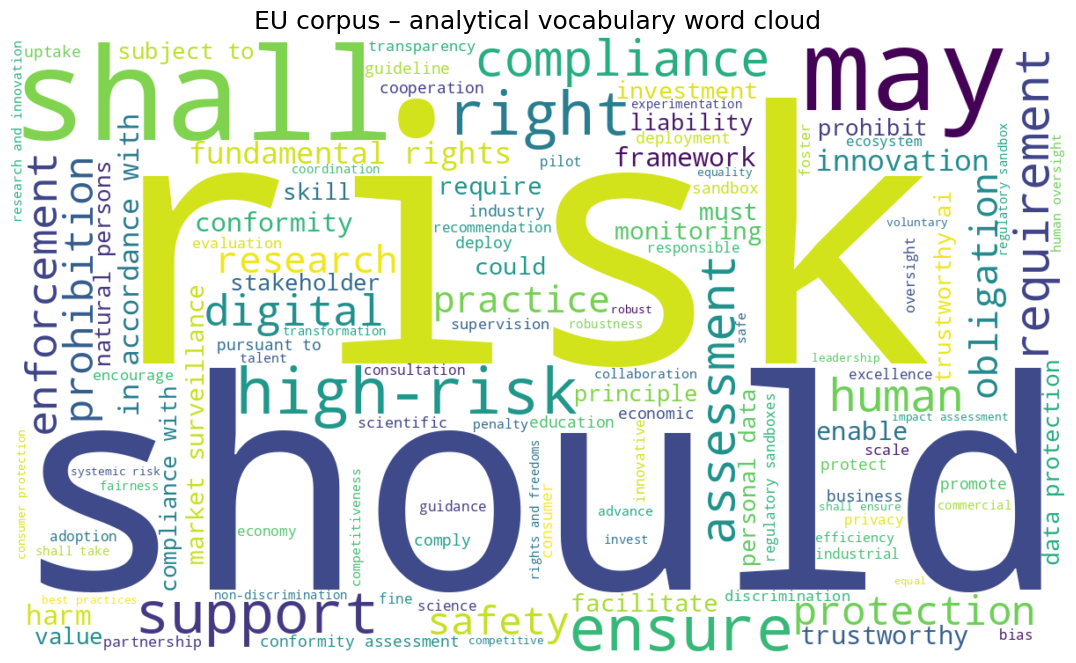

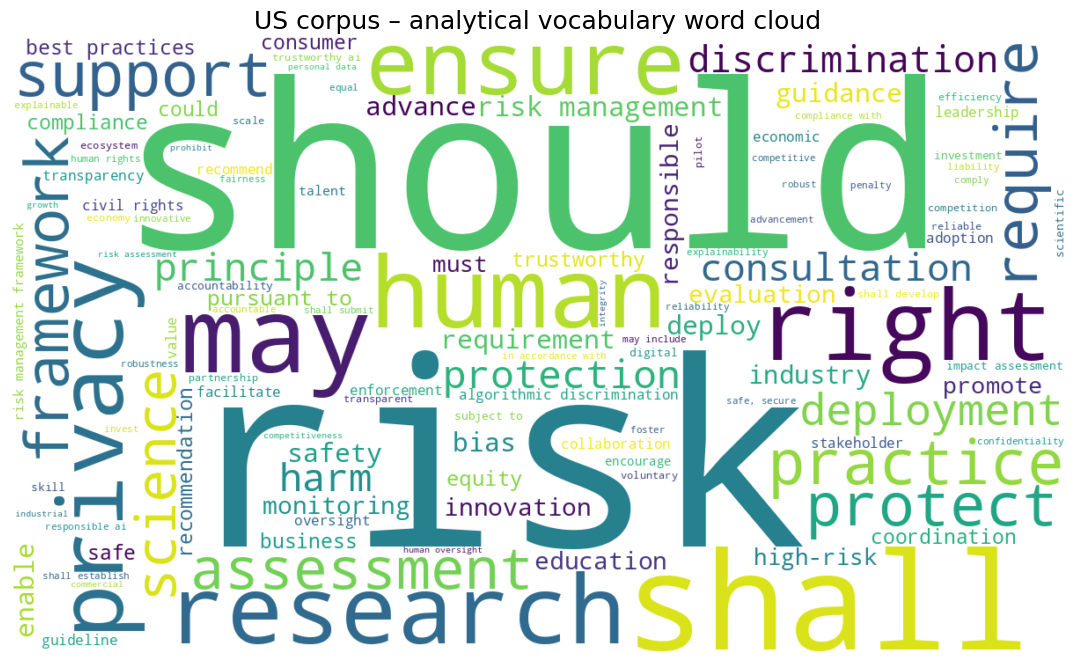

In [ ]:
# ============================================================
# Step 15 – EU and US analytical word clouds
# ============================================================

def generate_wordcloud_from_frequency_dict(freq_dict, title):
    wordcloud = WordCloud(
        width=1200,
        height=700,
        background_color="white",
        max_words=120,
        collocations=False
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(14, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.show()


# EU analytical vocabulary
eu_analytical_terms = analytical_vocabulary_df[
    analytical_vocabulary_df["jurisdiction"] == "EU"
]

eu_freq = (
    eu_analytical_terms
    .groupby("term")["absolute_frequency"]
    .sum()
    .to_dict()
)

# US analytical vocabulary
us_analytical_terms = analytical_vocabulary_df[
    analytical_vocabulary_df["jurisdiction"] == "US"
]

us_freq = (
    us_analytical_terms
    .groupby("term")["absolute_frequency"]
    .sum()
    .to_dict()
)

generate_wordcloud_from_frequency_dict(
    eu_freq,
    "EU corpus – analytical vocabulary word cloud"
)

generate_wordcloud_from_frequency_dict(
    us_freq,
    "US corpus – analytical vocabulary word cloud"
)

In [ ]:
# ============================================================
# Step 16 – Export final artefact outputs
# ============================================================

final_results_df.to_excel(
    "/content/full_corpus_results_v1_3.xlsx",
    index=False
)

final_results_summary.to_excel(
    "/content/full_corpus_summary_v1_3.xlsx",
    index=False
)

analytical_vocabulary_df.to_excel(
    "/content/full_analytical_vocabulary_table_v1_3.xlsx",
    index=False
)

top20_analytical_vocabulary_df.to_excel(
    "/content/top20_analytical_vocabulary_by_document_v1_3.xlsx",
    index=False
)

fig_full.write_html(
    "/content/full_corpus_regulatory_spectrum_v1_3.html"
)

fig_components_full.write_html(
    "/content/full_corpus_four_component_profile_v1_3.html"
)

print("Final artefact outputs exported successfully.")

Final artefact outputs exported successfully.


In [ ]:
# ============================================================
# Step 16B – Check exported final artefact files
# ============================================================

for file in sorted(os.listdir("/content")):
    if file.endswith((".xlsx", ".html", ".png")):
        print(file)

full_analytical_vocabulary_table_v1_3.xlsx
full_corpus_four_component_profile_v1_3.html
full_corpus_regulatory_spectrum_v1_3.html
full_corpus_results_v1_3.xlsx
full_corpus_summary_v1_3.xlsx
top20_analytical_vocabulary_by_document_v1_3.xlsx


In [ ]:
# ============================================================
# Step 17 – Heatmap of four-component intensity
# ============================================================

import plotly.express as px

heatmap_df = final_results_df[
    [
        "document_id",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000",
        "mandatory_per_1000",
        "voluntary_per_1000"
    ]
].copy()

heatmap_df = heatmap_df.set_index("document_id")

heatmap_df.columns = [
    "Rights/citizen safeguards",
    "Innovation",
    "Mandatory/control",
    "Voluntary/soft-law"
]

fig_heatmap = px.imshow(
    heatmap_df,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    title="Full Corpus v1.3: Heatmap of Four-Component Intensity",
    labels=dict(
        x="Analytical component",
        y="Document ID",
        color="Frequency per 1,000 tokens"
    )
)

fig_heatmap.update_layout(
    width=1100,
    height=900
)

fig_heatmap.show()

In [ ]:
# ============================================================
# Step 18 – Average position plot by document group
# ============================================================

average_position_df = (
    final_results_df
    .groupby("plot_group")
    .agg(
        mean_x_score=("x_score", "mean"),
        mean_y_score=("y_score_adjusted", "mean"),
        std_x_score=("x_score", "std"),
        std_y_score=("y_score_adjusted", "std"),
        document_count=("document_id", "count")
    )
    .reset_index()
)

average_position_df["mean_x_score"] = average_position_df["mean_x_score"].round(2)
average_position_df["mean_y_score"] = average_position_df["mean_y_score"].round(2)
average_position_df["std_x_score"] = average_position_df["std_x_score"].round(2)
average_position_df["std_y_score"] = average_position_df["std_y_score"].round(2)

average_position_df

,plot_group,mean_x_score,mean_y_score,std_x_score,std_y_score,document_count
0,EU,-2.05,-29.99,57.27,43.04,12
1,US,6.71,-11.05,44.01,41.20,11
2,US State / assumed in force,-72.53,55.24,NaN,NaN,1


In [ ]:
# ============================================================
# Step 18B – Visualise average positions
# ============================================================

fig_average = px.scatter(
    average_position_df,
    x="mean_x_score",
    y="mean_y_score",
    color="plot_group",
    size="document_count",
    text="plot_group",
    error_x="std_x_score",
    error_y="std_y_score",
    title="Full Corpus v1.3: Average Regulatory Position by Document Group",
    labels={
        "mean_x_score": "Rights/citizen safeguards (-100) ↔ Innovation (+100)",
        "mean_y_score": "Voluntary (-100) ↔ Mandatory (+100)",
        "plot_group": "Document group",
        "document_count": "Number of documents"
    },
    color_discrete_map={
        "EU": "blue",
        "US": "red",
        "US State / assumed in force": "orange"
    }
)

fig_average.add_vline(x=0, line_dash="dash")
fig_average.add_hline(y=0, line_dash="dash")

fig_average.update_traces(textposition="top center")

fig_average.update_layout(
    xaxis=dict(range=[-100, 100]),
    yaxis=dict(range=[-100, 100]),
    width=1100,
    height=800
)

fig_average.show()

In [ ]:
# ============================================================
# Step 19 – Assign each document to a regulatory quadrant
# ============================================================

def classify_quadrant(x, y):
    if x < 0 and y >= 0:
        return "Mandatory rights/citizen safeguards"
    elif x >= 0 and y >= 0:
        return "Mandatory innovation"
    elif x < 0 and y < 0:
        return "Voluntary rights/citizen safeguards"
    else:
        return "Voluntary innovation"

quadrant_df = final_results_df.copy()
quadrant_df["quadrant"] = quadrant_df.apply(
    lambda row: classify_quadrant(row["x_score"], row["y_score_adjusted"]),
    axis=1
)

quadrant_df[
    [
        "document_id",
        "document",
        "plot_group",
        "x_score",
        "y_score_adjusted",
        "quadrant"
    ]
].head(10)

,document_id,document,plot_group,x_score,y_score_adjusted,quadrant
0,EU_01,Communication: Artificial Intelligence for Europe,EU,44.02,-63.55,Voluntary innovation
1,EU_02,Coordinated Plan on Artificial Intelligence,EU,54.80,-58.65,Voluntary innovation
2,EU_03,Ethics Guidelines for Trustworthy AI,EU,-57.22,-43.89,Voluntary rights/citizen safeguards
3,EU_04,White Paper on Artificial Intelligence: A Euro...,EU,-26.55,-27.82,Voluntary rights/citizen safeguards
4,EU_05,Communication: Fostering a European approach t...,EU,8.68,-42.86,Voluntary innovation
5,EU_06,Coordinated Plan on Artificial Intelligence 20...,EU,53.72,-73.61,Voluntary innovation
6,EU_07,Regulation (EU) 2024/1689: Artificial Intellig...,EU,-65.47,48.88,Mandatory rights/citizen safeguards
7,EU_08,AI Pact,EU,-54.84,-33.86,Voluntary rights/citizen safeguards
8,EU_09,Apply AI Strategy,EU,62.03,-67.81,Voluntary innovation
9,EU_10,Communication from the Commission (2025) AI Co...,EU,76.56,-51.80,Voluntary innovation


In [ ]:
# ============================================================
# Step 19B – Count documents by quadrant and group
# ============================================================

quadrant_summary = (
    quadrant_df
    .groupby(["plot_group", "quadrant"])
    .size()
    .reset_index(name="document_count")
)

quadrant_summary

,plot_group,quadrant,document_count
0,EU,Mandatory rights/citizen safeguards,3
1,EU,Voluntary innovation,6
2,EU,Voluntary rights/citizen safeguards,3
3,US,Mandatory innovation,5
4,US,Voluntary innovation,2
5,US,Voluntary rights/citizen safeguards,4
6,US State / assumed in force,Mandatory rights/citizen safeguards,1


In [ ]:
# ============================================================
# Step 19C – Quadrant distribution chart
# ============================================================

fig_quadrant = px.bar(
    quadrant_summary,
    x="quadrant",
    y="document_count",
    color="plot_group",
    barmode="group",
    text="document_count",
    title="Full Corpus v1.3: Distribution of Documents Across Regulatory Quadrants",
    labels={
        "quadrant": "Regulatory quadrant",
        "document_count": "Number of documents",
        "plot_group": "Document group"
    },
    color_discrete_map={
        "EU": "blue",
        "US": "red",
        "US State / assumed in force": "orange"
    }
)

fig_quadrant.update_traces(textposition="outside")
fig_quadrant.update_layout(
    width=1300,
    height=750,
    xaxis_tickangle=-20
)

fig_quadrant.show()

In [ ]:
# ============================================================
# Step 20 – Top driver terms by jurisdiction
# ============================================================

jurisdiction_token_totals = (
    final_results_df
    .groupby("jurisdiction")["total_tokens"]
    .sum()
    .to_dict()
)

driver_terms_df = (
    analytical_vocabulary_df
    .groupby(["jurisdiction", "term", "category"], as_index=False)
    .agg(absolute_frequency=("absolute_frequency", "sum"))
)

driver_terms_df["jurisdiction_total_tokens"] = driver_terms_df["jurisdiction"].map(jurisdiction_token_totals)

driver_terms_df["corpus_frequency_per_1000"] = (
    driver_terms_df["absolute_frequency"] /
    driver_terms_df["jurisdiction_total_tokens"]
) * 1000

driver_terms_df["corpus_frequency_per_1000"] = driver_terms_df["corpus_frequency_per_1000"].round(3)

top_driver_terms_df = (
    driver_terms_df
    .sort_values(["jurisdiction", "corpus_frequency_per_1000"], ascending=[True, False])
    .groupby("jurisdiction", group_keys=False)
    .head(15)
    .reset_index(drop=True)
)

top_driver_terms_df

,jurisdiction,term,category,absolute_frequency,jurisdiction_total_tokens,corpus_frequency_per_1000
0,EU,risk,rights_citizen_safeguards,1256,129203,9.721
1,EU,should,voluntary_soft_law,1025,129203,7.933
2,EU,shall,mandatory_control,1024,129203,7.926
3,EU,may,voluntary_soft_law,804,129203,6.223
4,EU,high-risk,rights_citizen_safeguards,652,129203,5.046
5,EU,ensure,mandatory_control,641,129203,4.961
6,EU,right,rights_citizen_safeguards,603,129203,4.667
7,EU,support,voluntary_soft_law,551,129203,4.265
8,EU,assessment,rights_citizen_safeguards,524,129203,4.056
9,EU,requirement,mandatory_control,502,129203,3.885


In [ ]:
# ============================================================
# Step 20B – Visualise top driver terms by jurisdiction
# ============================================================

plot_top_driver_terms_df = top_driver_terms_df.sort_values(
    ["jurisdiction", "corpus_frequency_per_1000"],
    ascending=[True, True]
)

fig_driver_terms = px.bar(
    plot_top_driver_terms_df,
    x="corpus_frequency_per_1000",
    y="term",
    color="category",
    facet_col="jurisdiction",
    orientation="h",
    hover_data=["absolute_frequency"],
    title="Full Corpus v1.3: Top Driver Terms by Jurisdiction",
    labels={
        "corpus_frequency_per_1000": "Frequency per 1,000 corpus tokens",
        "term": "Term / phrase",
        "category": "Analytical category",
        "jurisdiction": "Jurisdiction"
    }
)

fig_driver_terms.update_layout(
    width=1400,
    height=800
)

fig_driver_terms.show()

In [ ]:
# ============================================================
# Step 21 – Slope chart: rights/citizen safeguards vs innovation
# ============================================================

slope_df = final_results_df[
    [
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000"
    ]
].copy()

slope_long_df = slope_df.melt(
    id_vars=["document_id", "document", "jurisdiction", "plot_group", "document_type"],
    value_vars=["rights_citizen_safeguards_per_1000", "innovation_per_1000"],
    var_name="component",
    value_name="frequency_per_1000"
)

slope_component_labels = {
    "rights_citizen_safeguards_per_1000": "Rights/citizen safeguards",
    "innovation_per_1000": "Innovation"
}

slope_long_df["component"] = slope_long_df["component"].map(slope_component_labels)

fig_slope = px.line(
    slope_long_df,
    x="component",
    y="frequency_per_1000",
    line_group="document_id",
    color="plot_group",
    hover_data=["document_id", "document", "document_type"],
    markers=True,
    title="Full Corpus v1.3: Slope Chart of Rights/Citizen Safeguards versus Innovation",
    labels={
        "component": "Analytical component",
        "frequency_per_1000": "Detected terms per 1,000 tokens",
        "plot_group": "Document group"
    },
    color_discrete_map={
        "EU": "blue",
        "US": "red",
        "US State / assumed in force": "orange"
    }
)

fig_slope.update_layout(
    width=1200,
    height=800
)

fig_slope.show()

In [ ]:
# ============================================================
# Step 21 – Split slope charts: EU and US
# ============================================================

slope_df = final_results_df[
    [
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000"
    ]
].copy()

slope_long_df = slope_df.melt(
    id_vars=[
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type"
    ],
    value_vars=[
        "rights_citizen_safeguards_per_1000",
        "innovation_per_1000"
    ],
    var_name="component",
    value_name="frequency_per_1000"
)

slope_component_labels = {
    "rights_citizen_safeguards_per_1000": "Rights/citizen safeguards",
    "innovation_per_1000": "Innovation"
}

slope_long_df["component"] = slope_long_df["component"].map(slope_component_labels)

In [ ]:
# ============================================================
# Step 21B – EU slope chart
# ============================================================

eu_slope_long_df = slope_long_df[
    slope_long_df["jurisdiction"] == "EU"
]

fig_slope_eu = px.line(
    eu_slope_long_df,
    x="component",
    y="frequency_per_1000",
    line_group="document_id",
    color="document_id",
    hover_data=["document", "document_type"],
    markers=True,
    title="EU Corpus v1.3: Rights/Citizen Safeguards versus Innovation",
    labels={
        "component": "Analytical component",
        "frequency_per_1000": "Detected terms per 1,000 tokens",
        "document_id": "Document ID"
    }
)

fig_slope_eu.update_layout(
    width=1000,
    height=750
)

fig_slope_eu.show()

In [ ]:
# ============================================================
# Step 21C – US slope chart
# ============================================================

us_slope_long_df = slope_long_df[
    slope_long_df["jurisdiction"] == "US"
]

fig_slope_us = px.line(
    us_slope_long_df,
    x="component",
    y="frequency_per_1000",
    line_group="document_id",
    color="plot_group",
    hover_data=["document_id", "document", "document_type"],
    markers=True,
    title="US Corpus v1.3: Rights/Citizen Safeguards versus Innovation",
    labels={
        "component": "Analytical component",
        "frequency_per_1000": "Detected terms per 1,000 tokens",
        "plot_group": "Document group"
    },
    color_discrete_map={
        "US": "red",
        "US State / assumed in force": "orange"
    }
)

fig_slope_us.update_layout(
    width=1000,
    height=750
)

fig_slope_us.show()

In [ ]:
# ============================================================
# Step 22 – Document-type comparison chart
# ============================================================

document_type_summary = (
    final_results_df
    .groupby("document_type")
    .agg(
        mean_x_score=("x_score", "mean"),
        mean_y_score=("y_score_adjusted", "mean"),
        document_count=("document_id", "count")
    )
    .reset_index()
)

document_type_summary["mean_x_score"] = document_type_summary["mean_x_score"].round(2)
document_type_summary["mean_y_score"] = document_type_summary["mean_y_score"].round(2)

document_type_summary

,document_type,mean_x_score,mean_y_score,document_count
0,Assumed adopted binding legislation,-59.24,54.03,1
1,Binding regulation,-65.47,48.88,1
2,Commission guidelines / AI Act implementation ...,-61.14,1.08,1
3,Executive Order,18.36,19.44,6
4,Expert group guidelines / soft law,-57.22,-43.89,1
5,Framework / guidance,-67.13,-77.95,1
6,Legislative bill / federal AI initiative legis...,51.82,-7.15,1
7,Policy action plan / strategy,52.58,-43.48,1
8,Policy blueprint / guidance,-59.84,-68.15,1
9,Policy communication / White Paper,-26.55,-27.82,1


In [ ]:
# ============================================================
# Step 22B – Visualise average scores by document type
# ============================================================

document_type_long = document_type_summary.melt(
    id_vars=["document_type", "document_count"],
    value_vars=["mean_x_score", "mean_y_score"],
    var_name="metric",
    value_name="average_score"
)

metric_labels = {
    "mean_x_score": "Average X-score",
    "mean_y_score": "Average Y-score"
}

document_type_long["metric"] = document_type_long["metric"].map(metric_labels)

fig_doc_type = px.bar(
    document_type_long,
    x="average_score",
    y="document_type",
    color="metric",
    orientation="h",
    barmode="group",
    hover_data=["document_count"],
    title="Full Corpus v1.3: Average Regulatory Position by Document Type",
    labels={
        "average_score": "Average score",
        "document_type": "Document type",
        "metric": "Score type",
        "document_count": "Number of documents"
    }
)

fig_doc_type.add_vline(x=0, line_dash="dash")

fig_doc_type.update_layout(
    width=1400,
    height=850
)

fig_doc_type.show()

In [ ]:
# ============================================================
# Step 23 – Export additional visualisations from Step 17 onwards
# ============================================================

fig_heatmap.write_html(
    "/content/full_corpus_heatmap_v1_3.html"
)

fig_average.write_html(
    "/content/full_corpus_average_position_v1_3.html"
)

fig_quadrant.write_html(
    "/content/full_corpus_quadrant_distribution_v1_3.html"
)

fig_driver_terms.write_html(
    "/content/full_corpus_top_driver_terms_by_jurisdiction_v1_3.html"
)

fig_slope_eu.write_html(
    "/content/full_corpus_slope_chart_eu_v1_3.html"
)

fig_slope_us.write_html(
    "/content/full_corpus_slope_chart_us_v1_3.html"
)

fig_doc_type.write_html(
    "/content/full_corpus_document_type_comparison_v1_3.html"
)

print("All additional visualisations exported successfully.")

All additional visualisations exported successfully.


In [ ]:
# ============================================================
# Step 24 – Export supporting data tables for additional visuals
# ============================================================

heatmap_df.to_excel(
    "/content/full_corpus_heatmap_data_v1_3.xlsx"
)

average_position_df.to_excel(
    "/content/full_corpus_average_position_data_v1_3.xlsx",
    index=False
)

quadrant_df[
    [
        "document_id",
        "document",
        "jurisdiction",
        "plot_group",
        "document_type",
        "x_score",
        "y_score_adjusted",
        "quadrant"
    ]
].to_excel(
    "/content/full_corpus_quadrant_assignment_v1_3.xlsx",
    index=False
)

quadrant_summary.to_excel(
    "/content/full_corpus_quadrant_summary_v1_3.xlsx",
    index=False
)

top_driver_terms_df.to_excel(
    "/content/full_corpus_top_driver_terms_by_jurisdiction_v1_3.xlsx",
    index=False
)

slope_long_df.to_excel(
    "/content/full_corpus_slope_chart_data_v1_3.xlsx",
    index=False
)

document_type_summary.to_excel(
    "/content/full_corpus_document_type_summary_v1_3.xlsx",
    index=False
)

print("All supporting data tables exported successfully.")

All supporting data tables exported successfully.


In [ ]:
# ============================================================
# Step 25 – Check exported files from Step 17 onwards
# ============================================================

for file in sorted(os.listdir("/content")):
    if (
        file.startswith("full_corpus_heatmap")
        or file.startswith("full_corpus_average_position")
        or file.startswith("full_corpus_quadrant")
        or file.startswith("full_corpus_top_driver")
        or file.startswith("full_corpus_slope")
        or file.startswith("full_corpus_document_type")
    ):
        print(file)

full_corpus_average_position_data_v1_3.xlsx
full_corpus_average_position_v1_3.html
full_corpus_document_type_comparison_v1_3.html
full_corpus_document_type_summary_v1_3.xlsx
full_corpus_heatmap_data_v1_3.xlsx
full_corpus_heatmap_v1_3.html
full_corpus_quadrant_assignment_v1_3.xlsx
full_corpus_quadrant_distribution_v1_3.html
full_corpus_quadrant_summary_v1_3.xlsx
full_corpus_slope_chart_data_v1_3.xlsx
full_corpus_slope_chart_eu_v1_3.html
full_corpus_slope_chart_us_v1_3.html
full_corpus_top_driver_terms_by_jurisdiction_v1_3.html
full_corpus_top_driver_terms_by_jurisdiction_v1_3.xlsx


In [ ]:
# ============================================================
# Step 26 – Create ZIP package with all final v1.3 artefact outputs
# ============================================================

import zipfile
import os

zip_filename = "/content/final_artefact_outputs_v1_3.zip"

files_to_zip = [
    # Main outputs
    "full_corpus_results_v1_3.xlsx",
    "full_corpus_summary_v1_3.xlsx",
    "full_analytical_vocabulary_table_v1_3.xlsx",
    "top20_analytical_vocabulary_by_document_v1_3.xlsx",
    "full_corpus_regulatory_spectrum_v1_3.html",
    "full_corpus_four_component_profile_v1_3.html",

    # Additional visual outputs
    "full_corpus_heatmap_v1_3.html",
    "full_corpus_average_position_v1_3.html",
    "full_corpus_quadrant_distribution_v1_3.html",
    "full_corpus_top_driver_terms_by_jurisdiction_v1_3.html",
    "full_corpus_slope_chart_eu_v1_3.html",
    "full_corpus_slope_chart_us_v1_3.html",
    "full_corpus_document_type_comparison_v1_3.html",

    # Supporting tables
    "full_corpus_heatmap_data_v1_3.xlsx",
    "full_corpus_average_position_data_v1_3.xlsx",
    "full_corpus_quadrant_assignment_v1_3.xlsx",
    "full_corpus_quadrant_summary_v1_3.xlsx",
    "full_corpus_top_driver_terms_by_jurisdiction_v1_3.xlsx",
    "full_corpus_slope_chart_data_v1_3.xlsx",
    "full_corpus_document_type_summary_v1_3.xlsx"
]

with zipfile.ZipFile(zip_filename, "w") as zipf:
    for file in files_to_zip:
        file_path = f"/content/{file}"
        if os.path.exists(file_path):
            zipf.write(file_path, arcname=file)
        else:
            print(f"File not found and not added: {file}")

print("ZIP package created:", zip_filename)

ZIP package created: /content/final_artefact_outputs_v1_3.zip


In [ ]:
from google.colab import files

files.download("/content/final_artefact_outputs_v1_3.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>